In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
nav_df = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv"
)

nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav_df.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [4]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
) * 100

In [6]:
nav_df[
    ["amfi_code", "date", "nav", "daily_return"]
].head(15)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-1.030568
2,100016,2022-01-05,521.7239,1.286515
3,100016,2022-01-06,515.7880,-1.137747
4,100016,2022-01-07,515.1639,-0.120999
5,100016,2022-01-10,510.7136,-0.863861
6,100016,2022-01-11,513.5542,0.556202
7,100016,2022-01-12,512.3195,-0.240423
8,100016,2022-01-13,510.2445,-0.405021
9,100016,2022-01-14,514.3636,0.807280


In [7]:
nav_df["daily_return"].describe()

count    45960.000000
mean         0.063105
std          1.029041
min         -5.810201
25%         -0.504211
50%          0.034021
75%          0.632376
max          6.471309
Name: daily_return, dtype: float64

In [8]:
output_path = "../data/processed/nav_daily_returns.csv"

nav_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: ../data/processed/nav_daily_returns.csv


In [10]:
nav_df = pd.read_csv(
    "../data/processed/nav_daily_returns.csv"
)

nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-1.030568
2,100016,2022-01-05,521.7239,1.286515
3,100016,2022-01-06,515.7880,-1.137747
4,100016,2022-01-07,515.1639,-0.120999


In [11]:
print("Start:", nav_df["date"].min())
print("End:", nav_df["date"].max())

Start: 2022-01-03 00:00:00
End: 2026-05-29 00:00:00


In [12]:
def calculate_cagr(group, years):
    
    group = group.sort_values("date")

    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    subset = group[group["date"] >= start_date]

    if len(subset) < 2:
        return np.nan

    beginning_nav = subset.iloc[0]["nav"]
    ending_nav = subset.iloc[-1]["nav"]

    if beginning_nav <= 0:
        return np.nan

    cagr = (
        (ending_nav / beginning_nav)
        ** (1 / years)
        - 1
    ) * 100

    return round(cagr, 2)

In [13]:
cagr_results = []

for fund, group in nav_df.groupby("amfi_code"):

    cagr_results.append({
        "amfi_code": fund,
        "cagr_1y": calculate_cagr(group, 1),
        "cagr_3y": calculate_cagr(group, 3),
        "cagr_5y": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-2.22,1.29,2.32
1,100025,3.70,3.92,3.91
2,100033,53.23,32.44,26.07
3,101206,47.92,28.97,20.44
4,101207,-23.99,-4.15,6.95


In [14]:
cagr_df.describe()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
count,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,19.428250,16.415250,14.541000
std,14534.998667,22.912863,12.206893,8.901683
min,100016.000000,-42.800000,-11.710000,1.030000
25%,118632.750000,7.382500,6.605000,6.012500
50%,119551.500000,17.475000,18.230000,14.475000
75%,120842.250000,27.165000,26.902500,21.255000
max,149324.000000,82.780000,35.110000,28.380000


In [15]:
cagr_df.sort_values(
    "cagr_5y",
    ascending=False
).head(10)

,amfi_code,cagr_1y,cagr_3y,cagr_5y
25,120505,29.60,31.78,28.38
21,119598,82.78,26.67,28.03
39,149324,65.14,27.00,27.92
36,148569,39.75,29.18,27.63
34,148567,20.36,34.00,26.80
30,120843,26.66,29.58,26.74
2,100033,53.23,32.44,26.07
38,149323,21.48,26.87,25.61
16,119094,22.26,35.11,24.45
19,119551,60.44,30.46,22.38


In [16]:
cagr_df.to_csv(
    "../data/processed/cagr_results.csv",
    index=False
)

print("CAGR file saved")

CAGR file saved


In [17]:
nav_df = pd.read_csv(
    "../data/processed/nav_daily_returns.csv"
)

nav_df["date"] = pd.to_datetime(nav_df["date"])

In [18]:
returns_df = nav_df.dropna(
    subset=["daily_return"]
).copy()

returns_df.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-1.030568
2,100016,2022-01-05,521.7239,1.286515
3,100016,2022-01-06,515.7880,-1.137747
4,100016,2022-01-07,515.1639,-0.120999
5,100016,2022-01-10,510.7136,-0.863861


In [19]:
risk_free_rate = 6.5

sharpe_results = []

for fund, group in returns_df.groupby("amfi_code"):

    mean_daily_return = group["daily_return"].mean()

    annual_return = mean_daily_return * 252

    annual_volatility = (
        group["daily_return"].std()
        * np.sqrt(252)
    )

    if annual_volatility == 0:
        sharpe = np.nan
    else:
        sharpe = (
            annual_return - risk_free_rate
        ) / annual_volatility

    sharpe_results.append({
        "amfi_code": fund,
        "annual_return": round(annual_return, 2),
        "annual_volatility": round(annual_volatility, 2),
        "sharpe_ratio": round(sharpe, 3)
    })

sharpe_df = pd.DataFrame(sharpe_results)

In [20]:
sharpe_df.head()

,amfi_code,annual_return,annual_volatility,sharpe_ratio
0,100016,3.57,14.55,-0.202
1,100025,4.29,3.91,-0.567
2,100033,27.21,18.94,1.094
3,101206,21.46,14.57,1.027
4,101207,10.70,25.80,0.163


In [21]:
sharpe_df.describe()

,amfi_code,annual_return,annual_volatility,sharpe_ratio
count,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,15.902250,14.944250,0.537200
std,14534.998667,8.757139,6.675125,0.573738
min,100016.000000,2.770000,0.490000,-0.816000
25%,118632.750000,6.882500,13.845000,0.064750
50%,119551.500000,16.320000,14.560000,0.647000
75%,120842.250000,22.125000,18.185000,1.005250
max,149324.000000,30.270000,25.800000,1.448000


In [22]:
sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

,amfi_code,annual_return,annual_volatility,sharpe_ratio
34,148567,27.06,14.19,1.448
30,120843,27.26,15.89,1.307
36,148569,28.33,17.67,1.235
19,119551,23.10,13.74,1.208
25,120505,29.27,19.29,1.180
38,149323,26.59,17.75,1.132
2,100033,27.21,18.94,1.094
9,118632,21.80,14.15,1.082
3,101206,21.46,14.57,1.027
24,120504,21.24,14.36,1.027


In [23]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio file saved")

Sharpe Ratio file saved


In [26]:
risk_free_rate = 6.5

sortino_results = []

for fund, group in returns_df.groupby("amfi_code"):

    mean_daily_return = group["daily_return"].mean()

    annual_return = mean_daily_return * 252

    downside_returns = group[
        group["daily_return"] < 0
    ]["daily_return"]

    if len(downside_returns) == 0:
        downside_deviation = np.nan
    else:
        downside_deviation = (
            downside_returns.std()
            * np.sqrt(252)
        )

    if (
        pd.isna(downside_deviation)
        or downside_deviation == 0
    ):
        sortino = np.nan
    else:
        sortino = (
            annual_return - risk_free_rate
        ) / downside_deviation

    sortino_results.append({
        "amfi_code": fund,
        "sortino_ratio": round(sortino, 3)
    })

sortino_df = pd.DataFrame(sortino_results)

In [27]:
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351
1,100025,-0.942
2,100033,1.829
3,101206,1.800
4,101207,0.277


In [28]:
sortino_df.describe()

,amfi_code,sortino_ratio
count,40.000000,40.000000
mean,120247.000000,0.923375
std,14534.998667,1.005401
min,100016.000000,-1.681000
25%,118632.750000,0.107000
50%,119551.500000,1.117000
75%,120842.250000,1.728000
max,149324.000000,2.386000


In [29]:
sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

,amfi_code,sortino_ratio
34,148567,2.386
30,120843,2.364
36,148569,2.147
19,119551,2.140
25,120505,2.029
38,149323,1.875
9,118632,1.850
2,100033,1.829
24,120504,1.805
3,101206,1.800


In [30]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio file saved")

Sortino Ratio file saved


In [31]:
benchmark_df = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [32]:
benchmark_df.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [33]:
benchmark_df = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

benchmark_df = benchmark_df.sort_values("date")

benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
5750,2022-01-03,CRISIL_LIQUID,2281.51
2300,2022-01-03,NIFTY_MIDCAP150,9721.79
6900,2022-01-03,CRISIL_GILT,1451.06
1150,2022-01-03,NIFTY100,17778.24


In [34]:
benchmark_df["benchmark_return"] = (
    benchmark_df["close_value"]
    .pct_change()
) * 100

benchmark_df.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
5750,2022-01-03,CRISIL_LIQUID,2281.51,-86.957426
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,326.112092
6900,2022-01-03,CRISIL_GILT,1451.06,-85.074148
1150,2022-01-03,NIFTY100,17778.24,1125.189861


In [35]:
benchmark_df[
    ["date",
     "close_value",
     "benchmark_return"]
].head(10)

,date,close_value,benchmark_return
0,2022-01-03,17492.79,NaN
5750,2022-01-03,2281.51,-86.957426
2300,2022-01-03,9721.79,326.112092
6900,2022-01-03,1451.06,-85.074148
1150,2022-01-03,17778.24,1125.189861
4600,2022-01-03,14837.07,-16.543651
3450,2022-01-03,26554.60,78.974690
1,2022-01-04,17689.64,-33.383896
5751,2022-01-04,2281.61,-87.101999
6901,2022-01-04,1453.26,-36.305504


In [36]:
benchmark_df[
    ["date",
     "close_value",
     "benchmark_return"]
].head(10)


,date,close_value,benchmark_return
0,2022-01-03,17492.79,NaN
5750,2022-01-03,2281.51,-86.957426
2300,2022-01-03,9721.79,326.112092
6900,2022-01-03,1451.06,-85.074148
1150,2022-01-03,17778.24,1125.189861
4600,2022-01-03,14837.07,-16.543651
3450,2022-01-03,26554.60,78.974690
1,2022-01-04,17689.64,-33.383896
5751,2022-01-04,2281.61,-87.101999
6901,2022-01-04,1453.26,-36.305504


In [37]:
from scipy.stats import linregress

In [38]:
alpha_beta_results = []

for fund, group in returns_df.groupby("amfi_code"):

    merged = pd.merge(
        group,
        benchmark_df[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope
    alpha = regression.intercept

    alpha_beta_results.append({
        "amfi_code": fund,
        "alpha": round(alpha, 4),
        "beta": round(beta, 4),
        "r_squared": round(
            regression.rvalue ** 2,
            4
        )
    })

alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

In [39]:
alpha_beta_df.head()

,amfi_code,alpha,beta,r_squared
0,100016,0.0149,-0.0,0.0
1,100025,0.0178,-0.0,0.0
2,100033,0.1052,0.0,0.0
3,101206,0.0827,0.0,0.0
4,101207,0.0436,-0.0,0.0


In [40]:
alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(10)

,amfi_code,alpha,beta,r_squared
39,149324,0.1175,0.0,0.0000
36,148569,0.1174,-0.0,0.0001
21,119598,0.1171,0.0,0.0000
34,148567,0.1107,-0.0,0.0001
25,120505,0.1104,0.0,0.0001
2,100033,0.1052,0.0,0.0000
30,120843,0.1034,0.0,0.0001
38,149323,0.1033,0.0,0.0000
16,119094,0.1011,0.0,0.0000
19,119551,0.0882,0.0,0.0001


In [41]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [42]:
alpha_beta_df.describe()

,amfi_code,alpha,beta,r_squared
count,40.000000,40.000000,40.0,40.000000
mean,120247.000000,0.062375,0.0,0.000045
std,14534.998667,0.033810,0.0,0.000068
min,100016.000000,0.012700,0.0,0.000000
25%,118632.750000,0.028425,0.0,0.000000
50%,119551.500000,0.062050,-0.0,0.000000
75%,120842.250000,0.086700,0.0,0.000100
max,149324.000000,0.117500,0.0,0.000300


In [43]:
print("NAV Start:", returns_df["date"].min())
print("NAV End:", returns_df["date"].max())

NAV Start: 2022-01-04 00:00:00
NAV End: 2026-05-29 00:00:00


In [44]:
print("Benchmark Start:", benchmark_df["date"].min())
print("Benchmark End:", benchmark_df["date"].max())

Benchmark Start: 2022-01-03 00:00:00
Benchmark End: 2026-05-29 00:00:00


In [45]:
sample_fund = returns_df["amfi_code"].iloc[0]

test = returns_df[
    returns_df["amfi_code"] == sample_fund
]

merged_test = pd.merge(
    test,
    benchmark_df[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print("Merged rows:", len(merged_test))

merged_test.head()

Merged rows: 8043


,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-04,515.0971,-1.030568,-33.383896
1,100016,2022-01-04,515.0971,-1.030568,-87.101999
2,100016,2022-01-04,515.0971,-1.030568,-36.305504
3,100016,2022-01-04,515.0971,-1.030568,1106.770984
4,100016,2022-01-04,515.0971,-1.030568,-43.240378


In [46]:
benchmark_df["benchmark_return"].describe()

count    8049.000000
mean      230.865117
std       509.973897
min       -97.174324
25%       -61.376765
50%         0.313724
75%       169.781227
max      3485.516528
Name: benchmark_return, dtype: float64

In [47]:

benchmark_df["index_name"].unique()


array(['NIFTY50', 'CRISIL_LIQUID', 'NIFTY_MIDCAP150', 'CRISIL_GILT',
       'NIFTY100', 'NIFTY500', 'BSE_SMALLCAP'], dtype=object)

In [48]:
benchmark_df["index_name"].value_counts()

index_name
NIFTY50            1150
CRISIL_LIQUID      1150
NIFTY_MIDCAP150    1150
CRISIL_GILT        1150
NIFTY100           1150
NIFTY500           1150
BSE_SMALLCAP       1150
Name: count, dtype: int64

In [49]:
benchmark_df = benchmark_df.sort_values(
    ["index_name", "date"]
)

benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")["close_value"]
    .pct_change()
) * 100

In [50]:
benchmark_df["benchmark_return"].describe()

count    8043.000000
mean        0.055304
std         0.875200
min        -3.971566
25%        -0.346574
50%         0.029628
75%         0.457604
max         4.185356
Name: benchmark_return, dtype: float64

In [51]:
benchmark_nifty = benchmark_df[
    benchmark_df["index_name"] == "NIFTY50"
].copy()


In [52]:
merged = pd.merge(
    group,
    benchmark_nifty[
        ["date", "benchmark_return"]
    ],
    on="date",
    how="inner"
)

In [54]:
alpha_beta_df.head()


,amfi_code,alpha,beta,r_squared
0,100016,0.0149,-0.0,0.0
1,100025,0.0178,-0.0,0.0
2,100033,0.1052,0.0,0.0
3,101206,0.0827,0.0,0.0
4,101207,0.0436,-0.0,0.0


In [55]:
alpha_beta_df.describe()

,amfi_code,alpha,beta,r_squared
count,40.000000,40.000000,40.0,40.000000
mean,120247.000000,0.062375,0.0,0.000045
std,14534.998667,0.033810,0.0,0.000068
min,100016.000000,0.012700,0.0,0.000000
25%,118632.750000,0.028425,0.0,0.000000
50%,119551.500000,0.062050,-0.0,0.000000
75%,120842.250000,0.086700,0.0,0.000100
max,149324.000000,0.117500,0.0,0.000300


In [56]:
def max_drawdown(nav_series):

    rolling_max = nav_series.cummax()

    drawdown = (
        nav_series - rolling_max
    ) / rolling_max

    return drawdown.min() * 100

In [57]:
mdd_results = []

for fund, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date")

    mdd_results.append({
        "amfi_code": fund,
        "max_drawdown": round(
            max_drawdown(group["nav"]),
            2
        )
    })

mdd_df = pd.DataFrame(mdd_results)

In [58]:
mdd_df.head()

,amfi_code,max_drawdown
0,100016,-24.73
1,100025,-4.31
2,100033,-16.22
3,101206,-11.29
4,101207,-35.45


In [59]:
mdd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [60]:
from sklearn.preprocessing import MinMaxScaler

In [61]:
scorecard_df = (
    cagr_df
    .merge(sharpe_df, on="amfi_code")
    .merge(sortino_df, on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(mdd_df, on="amfi_code")
)

scorecard_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y,annual_return,annual_volatility,sharpe_ratio,sortino_ratio,alpha,beta,r_squared,max_drawdown
0,100016,-2.22,1.29,2.32,3.57,14.55,-0.202,-0.351,0.0149,-0.0,0.0,-24.73
1,100025,3.70,3.92,3.91,4.29,3.91,-0.567,-0.942,0.0178,-0.0,0.0,-4.31
2,100033,53.23,32.44,26.07,27.21,18.94,1.094,1.829,0.1052,0.0,0.0,-16.22
3,101206,47.92,28.97,20.44,21.46,14.57,1.027,1.800,0.0827,0.0,0.0,-11.29
4,101207,-23.99,-4.15,6.95,10.70,25.80,0.163,0.277,0.0436,-0.0,0.0,-35.45


In [73]:
scaler = MinMaxScaler()

scorecard_df["cagr_score"] = scaler.fit_transform(
    scorecard_df[["cagr_5y"]]
)

scorecard_df["sharpe_score"] = scaler.fit_transform(
    scorecard_df[["sharpe_ratio"]]
)

scorecard_df["sortino_score"] = scaler.fit_transform(
    scorecard_df[["sortino_ratio"]]
)

scorecard_df["alpha_score"] = scaler.fit_transform(
    scorecard_df[["alpha"]]
)

scorecard_df["drawdown_score"] = scaler.fit_transform(
    scorecard_df[["max_drawdown"]]
)

In [74]:
scorecard_df["fund_score"] = (

      scorecard_df["cagr_score"] * 30
    + scorecard_df["sharpe_score"] * 25
    + scorecard_df["sortino_score"] * 25
    + scorecard_df["alpha_score"] * 10
    + scorecard_df["drawdown_score"] * 10

)

scorecard_df["fund_score"] = (
    scorecard_df["fund_score"]
    .round(2)
)

In [75]:
top_funds = scorecard_df.sort_values(
    "fund_score",
    ascending=False
)

top_funds.head(10)

,amfi_code,cagr_1y,cagr_3y,cagr_5y,annual_return,annual_volatility,sharpe_ratio,sortino_ratio,alpha,beta,r_squared,max_drawdown,cagr_score,sharpe_score,sortino_score,alpha_score,drawdown_score,fund_score
34,148567,20.36,34.00,26.80,27.06,14.19,1.448,2.386,0.1107,-0.0,0.0001,-11.27,0.942230,1.000000,1.000000,0.935115,0.787116,95.49
30,120843,26.66,29.58,26.74,27.26,15.89,1.307,2.364,0.1034,0.0,0.0001,-12.97,0.940037,0.937721,0.994591,0.865458,0.754717,92.71
36,148569,39.75,29.18,27.63,28.33,17.67,1.235,2.147,0.1174,-0.0,0.0001,-16.40,0.972578,0.905919,0.941234,0.999046,0.689346,92.24
25,120505,29.60,31.78,28.38,29.27,19.29,1.180,2.029,0.1104,0.0,0.0001,-18.19,1.000000,0.881625,0.912220,0.932252,0.655232,90.72
2,100033,53.23,32.44,26.07,27.21,18.94,1.094,1.829,0.1052,0.0,0.0000,-16.22,0.915539,0.843640,0.863044,0.882634,0.692777,85.89
38,149323,21.48,26.87,25.61,26.59,17.75,1.132,1.875,0.1033,0.0,0.0000,-17.25,0.898720,0.860424,0.874355,0.864504,0.673147,85.71
21,119598,82.78,26.67,28.03,30.27,25.14,0.945,1.675,0.1171,0.0,0.0000,-28.71,0.987203,0.777827,0.825178,0.996183,0.454736,84.20
19,119551,60.44,30.46,22.38,23.10,13.74,1.208,2.140,0.0882,0.0,0.0001,-15.01,0.780622,0.893993,0.939513,0.720420,0.715838,83.62
39,149324,65.14,27.00,27.92,30.09,24.84,0.950,1.620,0.1175,0.0,0.0000,-31.17,0.983181,0.780035,0.811655,1.000000,0.407852,83.37
16,119094,22.26,35.11,24.45,25.87,19.41,0.998,1.704,0.1011,0.0,0.0000,-20.96,0.856307,0.801237,0.832309,0.843511,0.602439,80.99


In [76]:
scorecard_df.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [77]:
best_fund = top_funds.iloc[0]["amfi_code"]

best_fund

np.float64(148567.0)

In [78]:
fund_nav = nav_df[
    nav_df["amfi_code"] == best_fund
].copy()

fund_nav = fund_nav.sort_values("date")

In [79]:
fund_nav["fund_growth"] = (
    fund_nav["nav"]
    / fund_nav["nav"].iloc[0]
) * 100

In [80]:
benchmark_nifty = benchmark_df[
    benchmark_df["index_name"] == "NIFTY50"
].copy()

benchmark_nifty = benchmark_nifty.sort_values(
    "date"
)

benchmark_nifty["benchmark_growth"] = (
    benchmark_nifty["close_value"]
    / benchmark_nifty["close_value"].iloc[0]
) * 100

In [81]:
comparison_df = pd.merge(
    fund_nav[["date", "fund_growth"]],
    benchmark_nifty[
        ["date", "benchmark_growth"]
    ],
    on="date",
    how="inner"
)

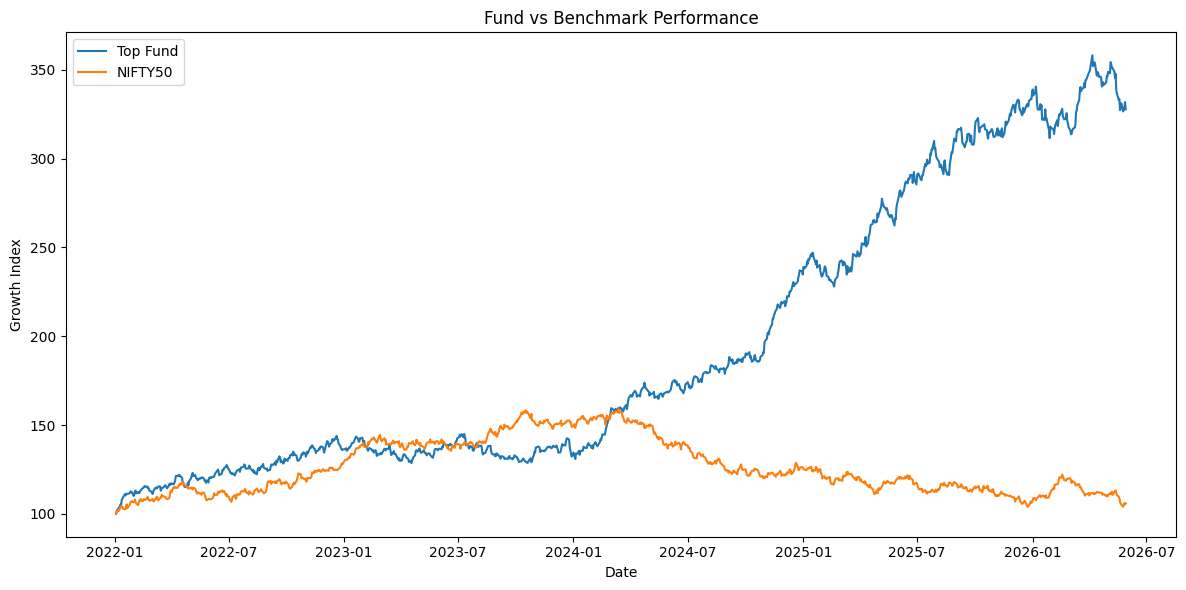

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    comparison_df["date"],
    comparison_df["fund_growth"],
    label="Top Fund"
)

plt.plot(
    comparison_df["date"],
    comparison_df["benchmark_growth"],
    label="NIFTY50"
)

plt.title(
    "Fund vs Benchmark Performance"
)

plt.xlabel("Date")
plt.ylabel("Growth Index")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300
)

plt.show()